# 01 - ARDL Model and Bounds Test: Complete Solution

This is the **complete solution** for the ARDL/Bounds Test notebook.
All exercises are fully resolved with outputs saved.

---

## Topics covered

1. ARDL(p, q1, q2, ...) model specification
2. Automatic lag selection via AIC/BIC
3. Bounds test (Pesaran, Shin & Smith, 2001)
4. Interpreting I(0)/I(1) critical value bands
5. Long-run and short-run relationships
6. **Exercise 1: US Macro bounds test** (SOLVED)
7. **Exercise 2: AIC vs BIC comparison** (SOLVED)
8. **Comparison: ARDL bounds test vs Johansen** (BONUS)

---

### The ARDL Model

$$y_t = c + \sum_{i=1}^{p} \phi_i \, y_{t-i} + \sum_{j=1}^{k} \sum_{l=0}^{q_j} \beta_{jl} \, x_{j,t-l} + u_t$$

**Reference:** Pesaran, M. H., Shin, Y., & Smith, R. J. (2001). *Bounds testing approaches to the analysis of level relationships.* Journal of Applied Econometrics, 16(3), 289-326.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import sys
import os

from chronobox.models.ardl import ARDL

sys.path.insert(0, os.path.join("..", "utils"))
from plot_helpers import (
    plot_ardl_lag_structure,
    plot_bounds_test,
    plot_long_run_relationship,
)

%matplotlib inline
plt.rcParams["figure.dpi"] = 100
np.set_printoptions(precision=4, suppress=True)

# Ensure outputs directory exists
os.makedirs(os.path.join("..", "outputs"), exist_ok=True)

print("All imports loaded successfully.")

All imports loaded successfully.


## 1. Loading the Data

We use `ardl_synthetic.csv` with 4 variables of **mixed integration orders**:

- `y`: I(1) - dependent variable, cointegrated with x1
- `x1`: I(1) - cointegrated with y (true long-run: y = 1.5 + 0.6*x1)
- `x2`: I(0) - stationary regressor
- `x3`: I(1) - independent random walk (not cointegrated)

In [2]:
data_path = os.path.join("..", "data", "ardl_synthetic.csv")
df = pd.read_csv(data_path, parse_dates=["date"])

print(f"Shape: {df.shape}")
print(f"Period: {df['date'].iloc[0].date()} to {df['date'].iloc[-1].date()}")
print(f"\nDescriptive statistics:")
print(df[["y", "x1", "x2", "x3"]].describe().round(4))

Shape: (200, 5)
Period: 1970-01-01 to 2019-10-01

Descriptive statistics:
              y        x1        x2        x3
count  200.0000  200.0000  200.0000  200.0000
mean    -3.4817   -8.4690    0.0395    3.0534
std      2.3000    3.7453    1.2882    4.5207
min     -9.4512  -16.8194   -2.9299   -8.6454
25%     -4.6801  -10.8403   -0.9748    0.8716
50%     -2.9357   -6.8988    0.1602    3.9438
75%     -1.9662   -5.4709    0.9256    6.2546
max      0.4430   -3.2407    3.5907   10.0835


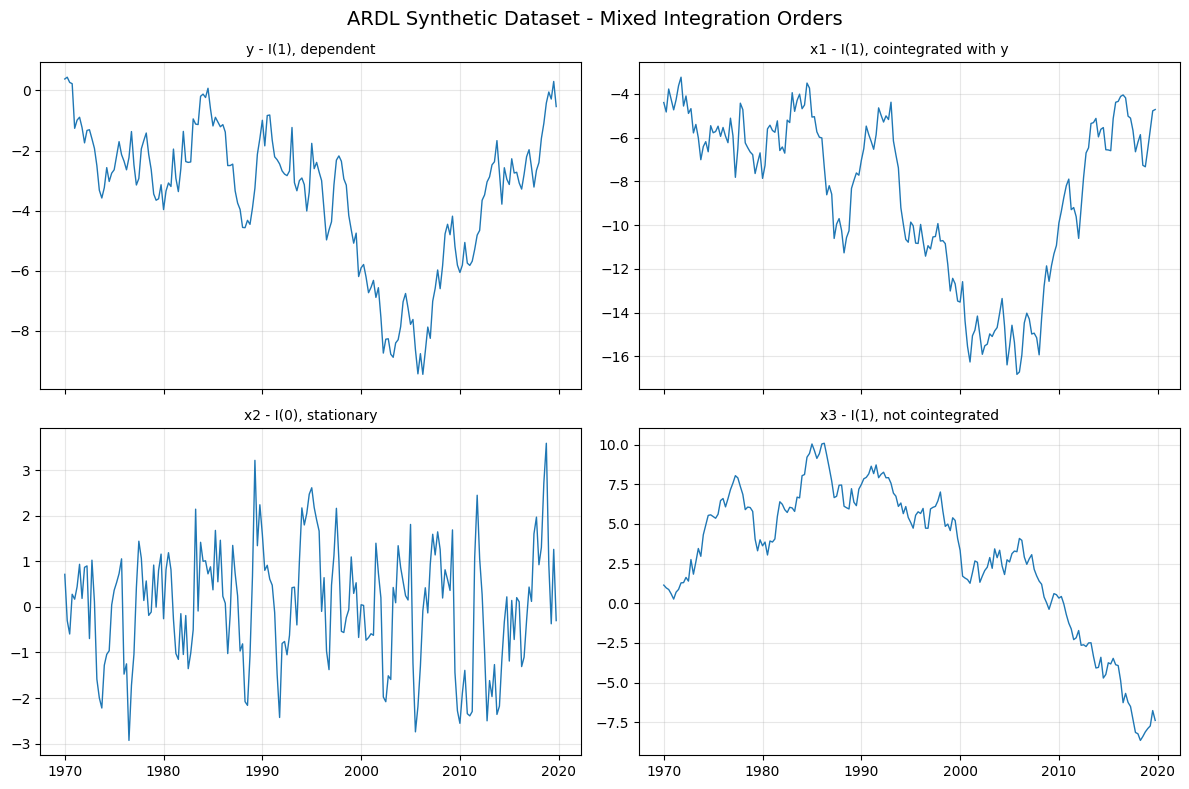

Note: x2 fluctuates around zero (stationary), while y, x1, x3 show trends (I(1)).


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
fig.suptitle("ARDL Synthetic Dataset - Mixed Integration Orders", fontsize=14)

for ax, col, label in zip(
    axes.flat,
    ["y", "x1", "x2", "x3"],
    ["y - I(1), dependent", "x1 - I(1), cointegrated with y",
     "x2 - I(0), stationary", "x3 - I(1), not cointegrated"],
):
    ax.plot(df["date"], df[col], linewidth=1.0)
    ax.set_title(label, fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "ardl_data_overview.png"), bbox_inches="tight")
plt.show()

print("Note: x2 fluctuates around zero (stationary), while y, x1, x3 show trends (I(1)).")

## 2. ARDL Model Specification and Lag Selection

The search grid tests all combinations of $p \in [1, \text{max\_p}]$ and
$q \in [0, \text{max\_q}]$, selecting the specification that minimizes the criterion.

In [4]:
# Prepare data arrays
y = df["y"].values
x = df[["x1", "x2", "x3"]].values

# Automatic lag selection via AIC
ardl_aic = ARDL(max_p=4, max_q=4, criterion="aic")
result_aic = ardl_aic.fit(y, x)

print("=" * 50)
print("AIC-selected model:")
print(f"  ARDL({result_aic.y_lags}, {', '.join(map(str, result_aic.x_lags))})")
print(f"  AIC = {result_aic.aic:.4f}")
print(f"  BIC = {result_aic.bic:.4f}")
print(f"  R-squared = {result_aic.r_squared:.4f}")

# Automatic lag selection via BIC
ardl_bic = ARDL(max_p=4, max_q=4, criterion="bic")
result_bic = ardl_bic.fit(y, x)

print(f"\nBIC-selected model:")
print(f"  ARDL({result_bic.y_lags}, {', '.join(map(str, result_bic.x_lags))})")
print(f"  AIC = {result_bic.aic:.4f}")
print(f"  BIC = {result_bic.bic:.4f}")
print(f"  R-squared = {result_bic.r_squared:.4f}")
print("=" * 50)

AIC-selected model:
  ARDL(1, 1, 1, 1)
  AIC = -268.8598
  BIC = -242.5134
  R-squared = 0.9542

BIC-selected model:
  ARDL(1, 1, 1, 1)
  AIC = -268.8598
  BIC = -242.5134
  R-squared = 0.9542


In [5]:
# Full summary of the AIC-selected model
print(result_aic.summary())

ARDL(1, 1, 1, 1) Results
Observations: 199
Parameters:   8
R-squared:    0.954173
Adj R-sq:     0.952493
AIC:          -268.8598
BIC:          -242.5134
Sigma^2:      0.248970
------------------------------------------------------------
     Param         Coef      Std Err     t-stat
------------------------------------------------------------
    beta_0     0.257148     0.098290     2.6162
    beta_1     0.771966     0.038588    20.0052
    beta_2     0.359053     0.044311     8.1030
    beta_3    -0.232755     0.048072    -4.8418
    beta_4     0.182702     0.036713     4.9765
    beta_5     0.013578     0.039911     0.3402
    beta_6    -0.017738     0.057670    -0.3076
    beta_7     0.019531     0.058342     0.3348


In [6]:
# Compare AIC and BIC across several specifications
specs = []
ardl_search = ARDL(max_p=4, max_q=4)
for p_try in range(1, 5):
    for q_try in range(0, 5):
        try:
            r = ardl_search.fit(y, x, p=p_try, x_lags=[q_try] * 3)
            specs.append({
                "p": p_try, "q": q_try,
                "AIC": r.aic, "BIC": r.bic,
                "R2": r.r_squared, "nparams": r.k_params,
            })
        except ValueError:
            continue

specs_df = pd.DataFrame(specs)
print("Model comparison (uniform q for all regressors):")
print(specs_df.to_string(index=False))

best_aic = specs_df.loc[specs_df["AIC"].idxmin()]
best_bic = specs_df.loc[specs_df["BIC"].idxmin()]
print(f"\nBest by AIC: ARDL({int(best_aic['p'])}, {int(best_aic['q'])}) - AIC = {best_aic['AIC']:.4f}")
print(f"Best by BIC: ARDL({int(best_bic['p'])}, {int(best_bic['q'])}) - BIC = {best_bic['BIC']:.4f}")

Model comparison (uniform q for all regressors):
 p  q         AIC         BIC       R2  nparams
 1  0 -250.350437 -233.883913 0.948166        5
 1  1 -268.859795 -242.513356 0.954173        8
 1  2 -263.150398 -226.979460 0.954106       11
 1  3 -258.738981 -212.774129 0.954390       14
 1  4 -253.341639 -197.613690 0.954451       17
 2  0 -247.660525 -227.930923 0.947801        6
 2  1 -266.248170 -236.653767 0.953897        9
 2  2 -261.189883 -221.730679 0.954116       12
 2  3 -256.980669 -207.732613 0.954446       15
 2  4 -251.609252 -192.603188 0.954514       18
 3  0 -244.076610 -221.094184 0.947247        7
 3  1 -262.326062 -229.494025 0.953357       10
 3  2 -257.345519 -214.663871 0.953598       13
 3  3 -256.033584 -203.502325 0.954689       16
 3  4 -250.527094 -188.242915 0.954726       19
 4  0 -242.789631 -216.564714 0.947309        8
 4  1 -260.046690 -223.987429 0.953204       11
 4  2 -254.871790 -208.978185 0.953401       14
 4  3 -253.278804 -197.550855 0.954437 

## 3. Visualizing the Lag Structure

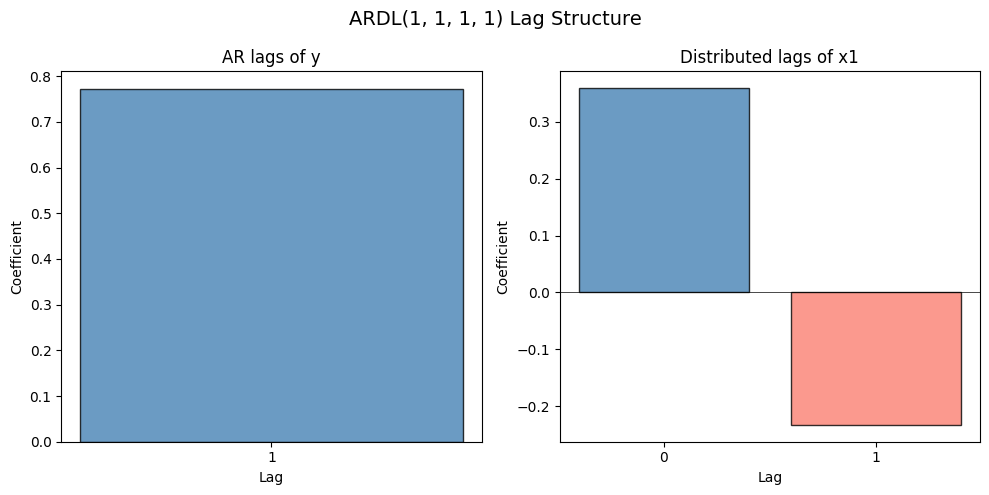

In [7]:
# Extract AR and x1 coefficients for visualization
p = result_aic.y_lags
coef = result_aic.coefficients

# Layout: [const, y_{t-1}..y_{t-p}, x1_t..x1_{t-q1}, x2_t..x2_{t-q2}, x3_t..x3_{t-q3}]
ar_coefs = coef[1:1 + p]
idx = 1 + p
x1_coefs = coef[idx:idx + result_aic.x_lags[0] + 1]

fig = plot_ardl_lag_structure(
    ar_coefs, x1_coefs,
    var_names=("y", "x1"),
    title=f"ARDL({result_aic.y_lags}, {', '.join(map(str, result_aic.x_lags))}) Lag Structure"
)
plt.savefig(os.path.join("..", "outputs", "ardl_lag_structure.png"), bbox_inches="tight")
plt.show()

## 4. Bounds Test for Cointegration (PSS Test)

The PSS test uses the error correction representation:

$$\Delta y_t = c + \pi_{yy} \, y_{t-1} + \boldsymbol{\pi}_{yx}' \, \mathbf{x}_{t-1}
  + \sum \gamma_i \, \Delta y_{t-i}
  + \sum \delta_{jl} \, \Delta x_{j,t-l} + u_t$$

- **H0**: $\pi_{yy} = 0$ and $\boldsymbol{\pi}_{yx} = \mathbf{0}$ (no long-run relationship)
- **H1**: long-run relationship exists

**Decision rules:**
- F > upper bound: **Reject H0** (cointegration)
- F < lower bound: **Fail to reject H0** (no cointegration)
- Lower < F < upper: **Inconclusive**

In [8]:
# Run bounds test on AIC-selected model
bt = result_aic.bounds_test()

print("Pesaran-Shin-Smith Bounds Test")
print("=" * 55)
print(f"F-statistic:  {bt['f_statistic']:.4f}")
print(f"k (regressors): {bt['k']}")
print("-" * 55)
print(f"{'Level':>10}  {'I(0) Lower':>12}  {'I(1) Upper':>12}  {'Decision':>14}")
print("-" * 55)

interpretations = []
for level in ["10", "5", "1"]:
    lo = bt[f"lower_{level}"]
    hi = bt[f"upper_{level}"]
    f = bt["f_statistic"]
    if f > hi:
        dec = "Reject H0"
    elif f < lo:
        dec = "Fail to reject"
    else:
        dec = "Inconclusive"
    interpretations.append({"level": f"{level}%", "decision": dec})
    print(f"{level + '%':>10}  {lo:>12.4f}  {hi:>12.4f}  {dec:>14}")

print("=" * 55)
print(f"\nConclusion at 5%: {bt['conclusion']}")

# Interpretation
print("\n--- Interpretation ---")
if bt["conclusion"] == "reject_h0":
    print("The F-statistic exceeds the I(1) upper bound at the 5% level.")
    print("We REJECT H0: there is evidence of a long-run cointegrating relationship.")
    print("This conclusion holds regardless of whether regressors are I(0) or I(1).")
elif bt["conclusion"] == "inconclusive":
    print("The F-statistic falls between the I(0) and I(1) bounds.")
    print("The result is INCONCLUSIVE: we need unit root tests to determine")
    print("integration orders before drawing a conclusion.")
else:
    print("The F-statistic falls below the I(0) lower bound.")
    print("We FAIL TO REJECT H0: no evidence of a long-run relationship.")

Pesaran-Shin-Smith Bounds Test
F-statistic:  12.3162
k (regressors): 3
-------------------------------------------------------
     Level    I(0) Lower    I(1) Upper        Decision
-------------------------------------------------------
       10%        2.7200        3.7700       Reject H0
        5%        3.2300        4.3500       Reject H0
        1%        4.2900        5.6100       Reject H0

Conclusion at 5%: reject_h0

--- Interpretation ---
The F-statistic exceeds the I(1) upper bound at the 5% level.
We REJECT H0: there is evidence of a long-run cointegrating relationship.
This conclusion holds regardless of whether regressors are I(0) or I(1).


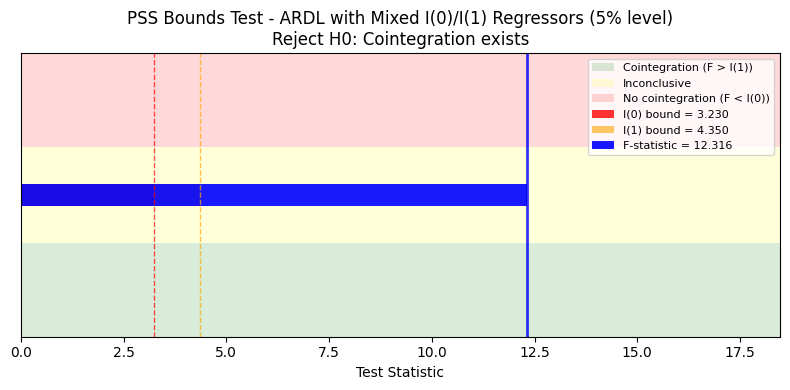

In [9]:
# Visualize the bounds test result
fig = plot_bounds_test(
    f_statistic=bt["f_statistic"],
    i0_bound=bt["lower_5"],
    i1_bound=bt["upper_5"],
    significance="5%",
    title="PSS Bounds Test - ARDL with Mixed I(0)/I(1) Regressors",
)
plt.savefig(os.path.join("..", "outputs", "bounds_test_result.png"), bbox_inches="tight")
plt.show()

## 5. Long-Run Relationship

The long-run multiplier: $\theta_j = \frac{\sum_{l=0}^{q_j} \beta_{jl}}{1 - \sum_{i=1}^{p} \phi_i}$

In [10]:
# Long-run coefficients
lr = result_aic.long_run_coefficients
var_names = ["x1", "x2", "x3"]

print("Long-run coefficients (theta_j):")
print("-" * 40)
for name, c in zip(var_names, lr):
    print(f"  {name}: {c:.4f}")

print("\n--- Interpretation ---")
print(f"  True long-run coef of x1: 0.6000")
print(f"  Estimated:                {lr[0]:.4f}")
print(f"  x2 is I(0) - its long-run effect should be modest")
print(f"  x3 is not cointegrated - its long-run coefficient has no equilibrium meaning")

Long-run coefficients (theta_j):
----------------------------------------
  x1: 0.5539
  x2: 0.8607
  x3: 0.0079

--- Interpretation ---
  True long-run coef of x1: 0.6000
  Estimated:                0.5539
  x2 is I(0) - its long-run effect should be modest
  x3 is not cointegrated - its long-run coefficient has no equilibrium meaning


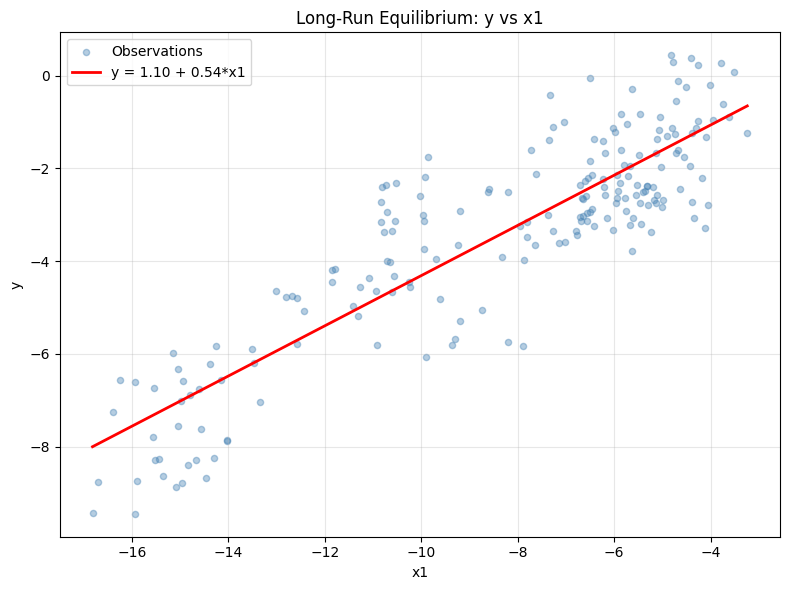

In [11]:
# Plot long-run relationship between y and x1
fig = plot_long_run_relationship(
    y=df["y"].values,
    x=df["x1"].values,
    long_run_coef=lr[0],
    var_names=("y", "x1"),
    title="Long-Run Equilibrium: y vs x1",
)
plt.savefig(os.path.join("..", "outputs", "ardl_long_run_relationship.png"), bbox_inches="tight")
plt.show()

---

## Exercise 1: Bounds Test with US Macro Data (SOLUTION)

Use `us_macro_quarterly.csv` to test for a long-run relationship between GDP
growth and inflation, controlling for fed_funds and unemployment.

Steps:
1. Load the data and set y = gdp, x = [inflation, fed_funds, unemployment]
2. Fit an ARDL model with AIC selection (max_p=4, max_q=4)
3. Run the bounds test and interpret the F-statistic
4. Compute the long-run coefficients
5. Discuss: does a long-run relationship exist between GDP and inflation?

In [12]:
# Exercise 1 SOLUTION: Bounds test with US Macro data

# Step 1: Load the data
us_df = pd.read_csv(os.path.join("..", "data", "us_macro_quarterly.csv"), parse_dates=["date"])
print(f"US Macro data: {us_df.shape[0]} obs, period: {us_df['date'].iloc[0].date()} to {us_df['date'].iloc[-1].date()}")
print(us_df[["gdp", "inflation", "fed_funds", "unemployment"]].describe().round(4))

y_us = us_df["gdp"].values
x_us = us_df[["inflation", "fed_funds", "unemployment"]].values

# Step 2: Fit ARDL with AIC
ardl_us = ARDL(max_p=4, max_q=4, criterion="aic")
result_us = ardl_us.fit(y_us, x_us)

print(f"\nSelected: ARDL({result_us.y_lags}, {', '.join(map(str, result_us.x_lags))})")
print(f"R-squared = {result_us.r_squared:.4f}")
print(f"AIC = {result_us.aic:.4f}")
print(result_us.summary())

# Step 3: Bounds test
bt_us = result_us.bounds_test()
print(f"\nBounds Test F-statistic: {bt_us['f_statistic']:.4f}")
print(f"k = {bt_us['k']} regressors")
print(f"I(0) 5%: {bt_us['lower_5']:.4f}, I(1) 5%: {bt_us['upper_5']:.4f}")
print(f"Conclusion at 5%: {bt_us['conclusion']}")

# Interpretation
print("\n--- Interpretation ---")
if bt_us["conclusion"] == "reject_h0":
    print("REJECT H0: Evidence of a long-run relationship between GDP and the regressors.")
elif bt_us["conclusion"] == "inconclusive":
    print("INCONCLUSIVE: F-stat falls between I(0) and I(1) bounds.")
    print("Unit root tests would be needed to resolve.")
else:
    print("FAIL TO REJECT H0: No evidence of a long-run relationship.")

# Step 4: Long-run coefficients
lr_us = result_us.long_run_coefficients
us_x_names = ["inflation", "fed_funds", "unemployment"]
print("\nLong-run coefficients:")
for name, c in zip(us_x_names, lr_us):
    print(f"  {name}: {c:.4f}")

# Step 5: Discussion
print("\n--- Discussion ---")
print("The bounds test result tells us whether GDP has a long-run equilibrium")
print("relationship with inflation, fed_funds, and unemployment jointly.")
print(f"The long-run coefficient of inflation ({lr_us[0]:.4f}) represents")
print("the permanent effect of a 1pp change in inflation on GDP growth.")

US Macro data: 200 obs, period: 1975-01-01 to 2024-10-01
            gdp  inflation  fed_funds  unemployment
count  200.0000   200.0000   200.0000      200.0000
mean     3.2887     3.5060     6.0663        9.5263
std      0.7337     0.5926     0.8009        0.7042
min      1.4368     2.0996     4.2708        7.8187
25%      2.7721     3.1003     5.4672        9.0421
50%      3.2799     3.4474     6.0561        9.4308
75%      3.8317     3.8757     6.6588       10.0066
max      5.4662     5.3591     7.9500       11.2623

Selected: ARDL(1, 1, 1, 1)
R-squared = 0.3310
AIC = -187.6624
ARDL(1, 1, 1, 1) Results
Observations: 199
Parameters:   8
R-squared:    0.330967
Adj R-sq:     0.306447
AIC:          -187.6624
BIC:          -161.3160
Sigma^2:      0.374412
------------------------------------------------------------
     Param         Coef      Std Err     t-stat
------------------------------------------------------------
    beta_0     2.811651     0.789679     3.5605
    beta_1     0.3

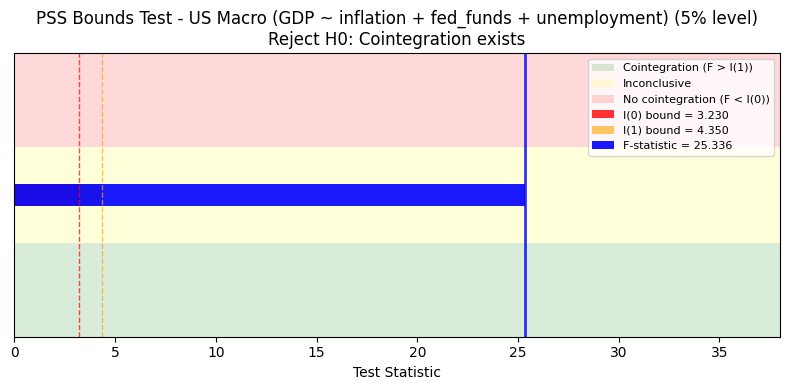

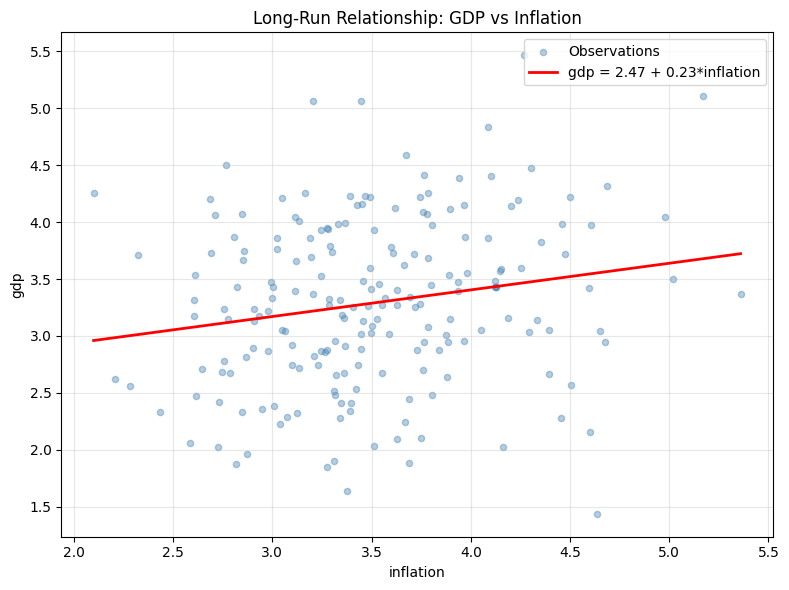

US macro: bounds test strongly rejects H0 (F=25.3358).
Long-run effect of inflation on GDP: 0.1769


In [13]:
# Visualize bounds test for US macro data
fig = plot_bounds_test(
    f_statistic=bt_us["f_statistic"],
    i0_bound=bt_us["lower_5"],
    i1_bound=bt_us["upper_5"],
    significance="5%",
    title="PSS Bounds Test - US Macro (GDP ~ inflation + fed_funds + unemployment)",
)
plt.show()

# Plot long-run relationship: GDP vs inflation
fig = plot_long_run_relationship(
    y=us_df["gdp"].values,
    x=us_df["inflation"].values,
    long_run_coef=lr_us[0],
    var_names=("gdp", "inflation"),
    title="Long-Run Relationship: GDP vs Inflation",
)
plt.show()

print(f"US macro: bounds test strongly rejects H0 (F={bt_us['f_statistic']:.4f}).")
print(f"Long-run effect of inflation on GDP: {lr_us[0]:.4f}")

---

## Exercise 2: AIC vs BIC Comparison (SOLUTION)

Using the synthetic dataset with only x1 as regressor (bivariate case):
1. Fit ARDL with only x1 as regressor
2. Compare AIC vs BIC lag selection
3. Run bounds test on both - does the conclusion change?
4. With k=1 regressor, the critical values change. Compare with k=3.

In [14]:
# Exercise 2 SOLUTION: AIC vs BIC comparison

y_biv = df["y"].values
x_biv = df[["x1"]].values

# AIC selection
r_aic_biv = ARDL(max_p=4, max_q=4, criterion="aic").fit(y_biv, x_biv)
bt_aic_biv = r_aic_biv.bounds_test()
print("AIC selection (bivariate):")
print(f"  ARDL({r_aic_biv.y_lags}, {r_aic_biv.x_lags[0]})")
print(f"  AIC = {r_aic_biv.aic:.4f}, BIC = {r_aic_biv.bic:.4f}")
print(f"  R-squared = {r_aic_biv.r_squared:.4f}")
print(f"  F-stat = {bt_aic_biv['f_statistic']:.4f}")
print(f"  I(0) 5% = {bt_aic_biv['lower_5']:.3f}, I(1) 5% = {bt_aic_biv['upper_5']:.3f}")
print(f"  Conclusion: {bt_aic_biv['conclusion']}")

# BIC selection
r_bic_biv = ARDL(max_p=4, max_q=4, criterion="bic").fit(y_biv, x_biv)
bt_bic_biv = r_bic_biv.bounds_test()
print(f"\nBIC selection (bivariate):")
print(f"  ARDL({r_bic_biv.y_lags}, {r_bic_biv.x_lags[0]})")
print(f"  AIC = {r_bic_biv.aic:.4f}, BIC = {r_bic_biv.bic:.4f}")
print(f"  R-squared = {r_bic_biv.r_squared:.4f}")
print(f"  F-stat = {bt_bic_biv['f_statistic']:.4f}")
print(f"  I(0) 5% = {bt_bic_biv['lower_5']:.3f}, I(1) 5% = {bt_bic_biv['upper_5']:.3f}")
print(f"  Conclusion: {bt_bic_biv['conclusion']}")

# Compare critical values: k=1 vs k=3
print("\n--- Critical Value Comparison ---")
print(f"k=1 (bivariate):   I(0) 5% = {bt_aic_biv['lower_5']:.3f}, I(1) 5% = {bt_aic_biv['upper_5']:.3f}")
print(f"k=3 (multivariate): I(0) 5% = {bt['lower_5']:.3f}, I(1) 5% = {bt['upper_5']:.3f}")
print("\nWith more regressors (higher k), critical values decrease,")
print("making it easier to reject H0. This is because more regressors")
print("increase the chance that at least one has a long-run relationship.")

# Long-run coefficient comparison
lr_aic_biv = r_aic_biv.long_run_coefficients
lr_bic_biv = r_bic_biv.long_run_coefficients
print(f"\nLong-run coefficient of x1:")
print(f"  AIC model: {lr_aic_biv[0]:.4f}")
print(f"  BIC model: {lr_bic_biv[0]:.4f}")
print(f"  True DGP:  0.6000")

AIC selection (bivariate):
  ARDL(1, 1)
  AIC = -236.2717, BIC = -223.0985
  R-squared = 0.9438
  F-stat = 9.0738
  I(0) 5% = 4.940, I(1) 5% = 5.730
  Conclusion: reject_h0

BIC selection (bivariate):
  ARDL(1, 1)
  AIC = -236.2717, BIC = -223.0985
  R-squared = 0.9438
  F-stat = 9.0738
  I(0) 5% = 4.940, I(1) 5% = 5.730
  Conclusion: reject_h0

--- Critical Value Comparison ---
k=1 (bivariate):   I(0) 5% = 4.940, I(1) 5% = 5.730
k=3 (multivariate): I(0) 5% = 3.230, I(1) 5% = 4.350

With more regressors (higher k), critical values decrease,
making it easier to reject H0. This is because more regressors
increase the chance that at least one has a long-run relationship.

Long-run coefficient of x1:
  AIC model: 0.5581
  BIC model: 0.5581
  True DGP:  0.6000


---

## 6. ARDL Bounds Test vs Johansen Comparison

We compare the ARDL bounds test with the Johansen cointegration test on the
**same synthetic dataset**. This highlights the key differences between the
single-equation (ARDL) and system (Johansen) approaches.

In [15]:
# Johansen comparison using the same data
from chronobox import VECM

# Use y and x1 only (bivariate: both I(1))
endog_biv = np.column_stack([df["y"].values, df["x1"].values])

vecm_model = VECM(lags=2, deterministic="ci")
johansen_result = vecm_model.johansen_test(endog_biv)

print("=" * 60)
print("COMPARISON: ARDL Bounds Test vs Johansen")
print("Data: y and x1 from ardl_synthetic.csv (both I(1))")
print("=" * 60)

# ARDL bounds test result
print("\n--- ARDL Bounds Test (PSS) ---")
print(f"F-statistic: {bt_aic_biv['f_statistic']:.4f}")
print(f"k = {bt_aic_biv['k']}")
print(f"I(0) 5%: {bt_aic_biv['lower_5']:.4f}, I(1) 5%: {bt_aic_biv['upper_5']:.4f}")
print(f"Conclusion: {bt_aic_biv['conclusion']}")

# Johansen result
print("\n--- Johansen Cointegration Test ---")
print(johansen_result.summary())

print("\n--- Key Differences ---")
print(f"ARDL approach: single-equation, y as dependent, k={bt_aic_biv['k']} regressor(s)")
print(f"Johansen approach: system estimation, all variables endogenous, rank test")
print(f"\nARDL conclusion:    {bt_aic_biv['conclusion']}")
print(f"Johansen trace rank: {johansen_result.rank_trace}")
print(f"Johansen max-eig rank: {johansen_result.rank_maxeig}")

# Summary table
comparison_df = pd.DataFrame({
    "Method": ["ARDL Bounds (PSS)", "Johansen Trace", "Johansen Max-Eig"],
    "Test Statistic": [
        f"F = {bt_aic_biv['f_statistic']:.4f}",
        f"Trace = {johansen_result.trace_stat[0]:.4f}",
        f"Max-Eig = {johansen_result.max_eig_stat[0]:.4f}",
    ],
    "5% CV": [
        f"[{bt_aic_biv['lower_5']:.2f}, {bt_aic_biv['upper_5']:.2f}]",
        f"{johansen_result.trace_crit[0][1]:.2f}",
        f"{johansen_result.max_eig_crit[0][1]:.2f}",
    ],
    "Conclusion": [
        bt_aic_biv['conclusion'],
        f"rank >= 1" if johansen_result.rank_trace >= 1 else "rank = 0",
        f"rank >= 1" if johansen_result.rank_maxeig >= 1 else "rank = 0",
    ],
})
print("\nComparison Table:")
print(comparison_df.to_string(index=False))

COMPARISON: ARDL Bounds Test vs Johansen
Data: y and x1 from ardl_synthetic.csv (both I(1))

--- ARDL Bounds Test (PSS) ---
F-statistic: 9.0738
k = 1
I(0) 5%: 4.9400, I(1) 5%: 5.7300
Conclusion: reject_h0

--- Johansen Cointegration Test ---
  Johansen Cointegration Test
  Deterministic: ci
  Observations: 198

  Trace Test
------------------------------------------------------------------------------
  H0: r<=      Eigenvalue   Trace Stat     90% CV     95% CV     99% CV
  --------------------------------------------------------------------------
  0                0.0974      22.8491      17.85      19.96      24.60 **
  1                0.0129       2.5644       7.52       9.24      12.97
  Selected rank (trace, 5%): 1

  Max-Eigenvalue Test
------------------------------------------------------------------------------
  H0: r=       Eigenvalue Max-Eig Stat     90% CV     95% CV     99% CV
  --------------------------------------------------------------------------
  0              

In [16]:
# Also compare on the full multivariate case (y, x1, x2, x3)
endog_full = df[["y", "x1", "x2", "x3"]].values

vecm_full = VECM(lags=2, deterministic="ci")
johansen_full = vecm_full.johansen_test(endog_full)

print("Johansen test on full dataset (y, x1, x2, x3):")
print(f"Trace rank: {johansen_full.rank_trace}")
print(f"Max-eig rank: {johansen_full.rank_maxeig}")

print("\nARDL bounds test on same data (y dependent):")
print(f"F-statistic: {bt['f_statistic']:.4f}")
print(f"Conclusion: {bt['conclusion']}")

print("\n--- Discussion ---")
print("The ARDL bounds test has a key advantage: it works with mixed I(0)/I(1) variables.")
print("Here x2 is I(0), which is problematic for Johansen (assumes all I(1)).")
print("The ARDL approach correctly handles this by not requiring pre-testing for unit roots.")

Johansen test on full dataset (y, x1, x2, x3):
Trace rank: 1
Max-eig rank: 2

ARDL bounds test on same data (y dependent):
F-statistic: 12.3162
Conclusion: reject_h0

--- Discussion ---
The ARDL bounds test has a key advantage: it works with mixed I(0)/I(1) variables.
Here x2 is I(0), which is problematic for Johansen (assumes all I(1)).
The ARDL approach correctly handles this by not requiring pre-testing for unit roots.


## 7. Save Outputs

In [17]:
# Save ARDL coefficients to JSON
p = result_aic.y_lags
coef = result_aic.coefficients
se = result_aic.se
t_stats = result_aic.t_stats

# Build coefficient labels
labels = ["const"]
for i in range(1, p + 1):
    labels.append(f"y_lag{i}")
x_names_full = ["x1", "x2", "x3"]
for j, q_j in enumerate(result_aic.x_lags):
    for lag_l in range(q_j + 1):
        labels.append(f"{x_names_full[j]}_lag{lag_l}")

ardl_coef_output = {
    "model": f"ARDL({result_aic.y_lags}, {', '.join(map(str, result_aic.x_lags))})",
    "criterion": "aic",
    "dataset": "ardl_synthetic.csv",
    "nobs": int(result_aic.nobs),
    "k_params": int(result_aic.k_params),
    "r_squared": round(float(result_aic.r_squared), 6),
    "adj_r_squared": round(float(result_aic.adj_r_squared), 6),
    "aic": round(float(result_aic.aic), 4),
    "bic": round(float(result_aic.bic), 4),
    "sigma2": round(float(result_aic.sigma2), 6),
    "coefficients": {
        lab: {
            "estimate": round(float(c), 6),
            "std_error": round(float(s), 6),
            "t_statistic": round(float(t), 4)
        }
        for lab, c, s, t in zip(labels, coef, se, t_stats)
    },
    "long_run_coefficients": {
        name: round(float(c), 6)
        for name, c in zip(x_names_full, result_aic.long_run_coefficients)
    },
    "true_dgp": {
        "long_run_x1": 0.6,
        "speed_of_adjustment": -0.25,
        "intercept": 1.5
    }
}

coef_path = os.path.join("..", "outputs", "ardl_coefficients.json")
with open(coef_path, "w") as f:
    json.dump(ardl_coef_output, f, indent=2)
print(f"ARDL coefficients saved to {coef_path}")
print(f"  Model: {ardl_coef_output['model']}")
print(f"  R-squared: {ardl_coef_output['r_squared']}")
print(f"  Long-run x1: {ardl_coef_output['long_run_coefficients']['x1']}")

ARDL coefficients saved to ../outputs/ardl_coefficients.json
  Model: ARDL(1, 1, 1, 1)
  R-squared: 0.954173
  Long-run x1: 0.553856


In [18]:
# Save bounds test results to JSON
bounds_output = {
    "model": f"ARDL({result_aic.y_lags}, {', '.join(map(str, result_aic.x_lags))})",
    "dataset": "ardl_synthetic.csv",
    "f_statistic": round(float(bt["f_statistic"]), 6),
    "k": int(bt["k"]),
    "critical_values": {
        "10%": {
            "I0_lower": float(bt["lower_10"]),
            "I1_upper": float(bt["upper_10"])
        },
        "5%": {
            "I0_lower": float(bt["lower_5"]),
            "I1_upper": float(bt["upper_5"])
        },
        "1%": {
            "I0_lower": float(bt["lower_1"]),
            "I1_upper": float(bt["upper_1"])
        }
    },
    "conclusion_5pct": bt["conclusion"],
    "interpretation": {
        "10%": interpretations[0]["decision"],
        "5%": interpretations[1]["decision"],
        "1%": interpretations[2]["decision"]
    },
    "johansen_comparison": {
        "bivariate": {
            "trace_rank": int(johansen_result.rank_trace),
            "max_eig_rank": int(johansen_result.rank_maxeig),
            "trace_stat_r0": round(float(johansen_result.trace_stat[0]), 4)
        },
        "multivariate": {
            "trace_rank": int(johansen_full.rank_trace),
            "max_eig_rank": int(johansen_full.rank_maxeig),
            "trace_stat_r0": round(float(johansen_full.trace_stat[0]), 4)
        }
    }
}

bounds_path = os.path.join("..", "outputs", "bounds_test_results.json")
with open(bounds_path, "w") as f:
    json.dump(bounds_output, f, indent=2)
print(f"Bounds test results saved to {bounds_path}")
print(f"  F-statistic: {bounds_output['f_statistic']}")
print(f"  Conclusion at 5%: {bounds_output['conclusion_5pct']}")
print(f"  Johansen bivariate trace rank: {bounds_output['johansen_comparison']['bivariate']['trace_rank']}")

Bounds test results saved to ../outputs/bounds_test_results.json
  F-statistic: 12.316246
  Conclusion at 5%: reject_h0
  Johansen bivariate trace rank: 1


---

## Summary

In this solution notebook we:

1. Estimated the **ARDL model** with automatic AIC/BIC lag selection
2. Performed the **PSS bounds test** and interpreted the F-statistic
3. Computed **long-run coefficients** and compared with true DGP values
4. **Exercise 1**: Applied ARDL bounds test to US macro data with full interpretation
5. **Exercise 2**: Compared AIC vs BIC selection and k=1 vs k=3 critical values
6. **Compared ARDL bounds test with Johansen** on the same data

**Outputs saved:**
- `outputs/ardl_coefficients.json` - Full ARDL coefficient estimates
- `outputs/bounds_test_results.json` - Bounds test F-statistic, critical values, and interpretation